In [1]:
%matplotlib inline

# Module 13 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

# The Problem

When we last left our agent in Module 4, it was wandering around a world filled with plains, forests, swamps, hills and mountains. This presupposes a map with known terrain:

```
......
...**.
...***
..^...
..~^..
```

but what if all we know is that we have some area of interest, that we've reduced to a GPS grid:

```
??????
??????
??????
??????
??????
```

and the agent has to determine what kind of terrain is to the left, front and right of it?

Assuming the agent has a very simple visual sensor that constructs a 4x4 grayscale image for each of the three directions, it might it could see something like this:

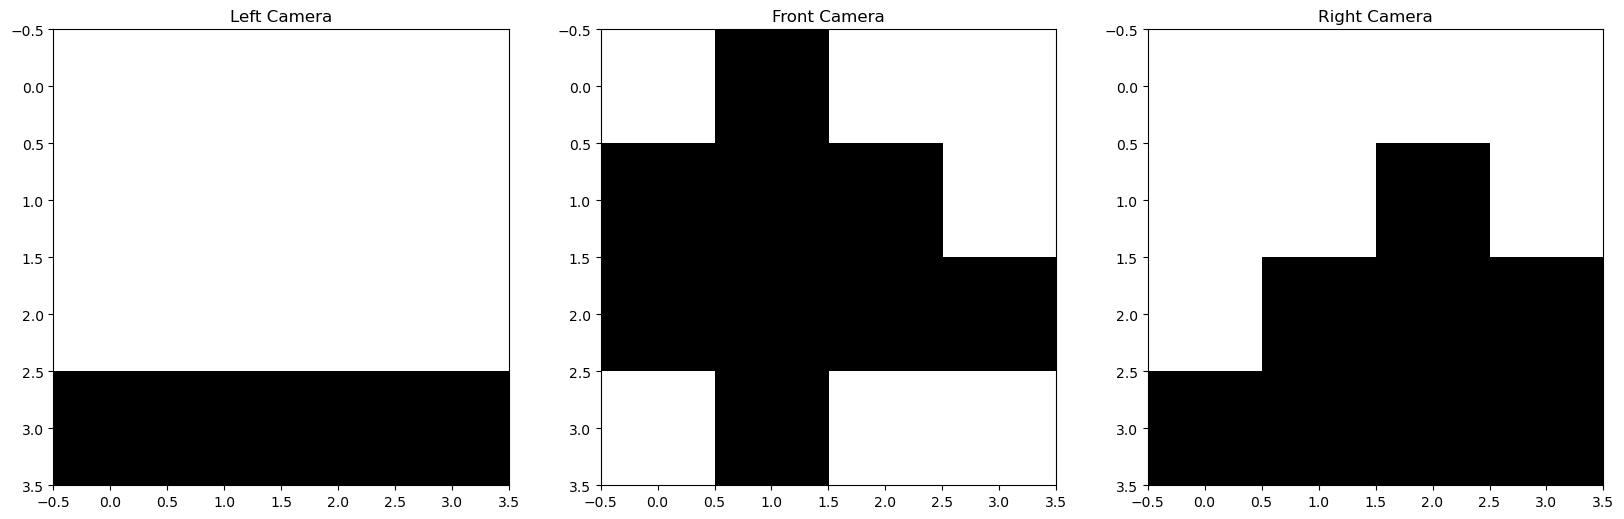

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

plain =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0,1.0, 1.0, 1.0, 1.0]
forest = [0.0, 1.0, 0.0, 0.0,1.0, 1.0, 1.0, 0.0,1.0, 1.0, 1.0, 1.0,0.0, 1.0, 0.0, 0.0]
hills =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 1.0, 0.0,0.0, 1.0, 1.0, 1.0,1.0, 1.0, 1.0, 1.0]
swamp =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0,1.0, 0.0, 1.0, 0.0,1.0, 1.0, 1.0, 1.0]

figure = plt.figure(figsize=(20,6))

axes = figure.add_subplot(1, 3, 1)
pixels = np.array([255 - p * 255 for p in plain], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Left Camera")
axes.imshow(pixels, cmap='gray')

axes = figure.add_subplot(1, 3, 2)
pixels = np.array([255 - p * 255 for p in forest], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Front Camera")
axes.imshow(pixels, cmap='gray')

axes = figure.add_subplot(1, 3, 3)
pixels = np.array([255 - p * 255 for p in hills], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Right Camera")
axes.imshow(pixels, cmap='gray')

plt.show()
plt.close()

which would be plains, forest and hills respectively.


## The Assignment

In Assignment 12, we applied a logistic regression to determine if something was "hills" or "not hills". For this programming assignment your task is to write an artificial neural network that determines what kind of terrain it is. This is a multi-class problem.

For a starting point, you can refer to Pseudocode and the Self-Check.

## Data

As before, we have clean examples of the different types of terrain but based on the location, the registration can be a bit off for some of the types and the visual sensor is often blurry.

Here are the clean examples with different registrations: 

In [3]:
clean_data = {
    "plains": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, "plains"]
    ],
    "forest": [
        [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, "forest"],
        [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, "forest"]
    ],
    "hills": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, "hills"]
    ],
    "swamp": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "swamp"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, "swamp"]        
    ]
}

Let's create a function that allows us to view any of these:

In [4]:
def view_sensor_image( data):
    figure = plt.figure(figsize=(4,4))
    axes = figure.add_subplot(1, 1, 1)
    pixels = np.array([255 - p * 255 for p in data[:-1]], dtype='uint8')
    pixels = pixels.reshape((4, 4))
    axes.set_title( "Left Camera:" + data[-1])
    axes.imshow(pixels, cmap='gray')
    plt.show()
    plt.close()

"I think that I shall never see a thing so lovely as a tree."

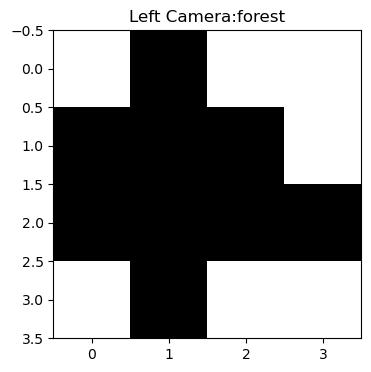

In [5]:
view_sensor_image( clean_data[ "forest"][0])

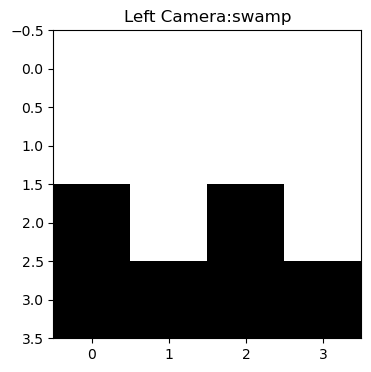

In [6]:
view_sensor_image( clean_data["swamp"][0])

The data that comes in, however, is noisy. The values are never exactly 0 and 1. In order to mimic this we need a `blur` function.

We will assume that noise is normally distributed. For values that should be 0, the noisy values are distributed $N(0.10, 0.05)$. For values should be 1, the noisy values are distributed $N(0.9, 0.10)$.

In [7]:
def blur( data):
    def apply_noise( value):
        if value < 0.5:
            v = random.gauss( 0.10, 0.05)
            if v < 0.0:
                return 0.0
            if v > 0.75:
                return 0.75
            return v
        else:
            v = random.gauss( 0.90, 0.10)
            if v < 0.25:
                return 0.25
            if v > 1.00:
                return 1.00
            return v
    noisy_readings = [apply_noise( v) for v in data[0:-1]]
    return noisy_readings + [data[-1]]

We can see how this affects what the agent *actually* sees.

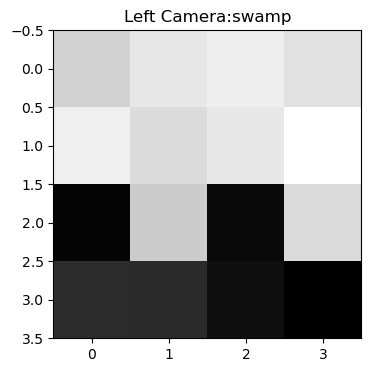

In [8]:
view_sensor_image( blur( clean_data["swamp"][0]))

You are going to want to write four (4) functions:

1. `generate_data`
2. `learn_model`
3. `apply_model`

### `generate_data`

With the clean examples and the `blur` function, we have an unlimited amount of data for training and testing our classifier, an ANN that determines if a sensor image is hills, swamp, forest or plains.

In classification, there is a general problem called the "unbalanced class problem". In general, we want our training data to have the same number of classes for each class. This means you should probably generate training data with, say, 100 of each type.

But what do we do about the class label with the neural network?

In this case, we can do "one hot". Instead of `generate_data` outputing a single 0 or 1, it should output a vector of 0's and 1's so that $y$ is now a vector as well as $x$. We can use the first position for hill, the second for swamp, the third for forest and the fourth for plains:

```
[0, 1, 0, 0]
```

what am I? swamp.

Unlike logistic regression, you should set the *biases* inside the neural network (the implict $x_0$ = 1) because there are going to be lot of them (one for every hidden and output node).

`generate_data` now only needs to take how many you want of each class:

`generate_data( clean_data, 100)`

generates 100 hills, 100 swamp, 100 forest, 100 plains and transforms $y$ into the respective "one hot" encoding. You can use the code from Module 12 as a starting point.

### `learn_model`

`learn_model` is the function that takes in training data and actually learns the ANN. If you're up to it, you can implement a vectorized version using Numpy but you might start with the loopy version first.

*In the lecture, I mentioned that you usually should mean normalize your data but you don't need to do that in this case because the data is already on the range 0-1.*

You should add a parameter to indicate how many nodes the hidden layer should have.

When verbose is True, you should print out the error so you can see that it is getting smaller.

When developing your algorithm, you need to watch the error so you'll set verbose=True to start. You should print it out every iteration and make sure it is declining. You'll have to experiment with both epsilon and alpha; and it doesn't hurt to make alpha adaptive (if the error increases, make alpha = alpha / 10).

When you know that your algorithm is working, change your code so that the error is printed out only every 1,000 iterations (it takes a lot of iterations for this problem to converge, depending on your parameter values--start early).

`learn_model` returns the neural network. The hidden layer will be one vector of thetas for each hidden node. And the output layer will have its own thetas, one for each output (4 in this case). Return it as a Tuple: (List of List, List of List).

### `apply_model`

`apply_model` takes the ANN (the model) and either labeled or unlabeled data. If the data is unlabeled, it will return predictions for each observation as a List of Tuples of the inferred value (0 or 1) and the actual probability (so something like (1, 0.73) or (0, 0.19) so you have [(0, 0.30), (1, 0.98), (0, 0.87), (0, 0.12)]. Note that unlike the logistic regression, the threshold for 1 is not 0.5 but which value is largest (0.98 in this case).

If the data is labeled, you will return a List of List of Tuples of the actual value (0 or 1) and the predicted value (0 or 1). For a single data point, you'll have the pairs of actual values [(0, 1), (0, 0), (0, 0), (1, 0)] is a misclassification and [(0, 0), (0, 0), (1, 1), (0, 0)] will be a correct classification. Then you have a List of *those*, one for each observation.

###  simple evaluation

We have an "unlimited" supply of data so we'll just generate a training set and then a test set and see how well our neural network does. Use the error rate (incorrect classifications/total examples) for your evaluation metric. We'll learn about more sophisticated 

1. generate training set (how many do you think you need?)
2. generate test set (how many is a good "test" of the network you built?)
3. loop over [2, 4, 8] hidden nodes:
    1. train model and apply to train data, calculate error rate.
    2. apply to test data and calculate error rate.
    3. print error rate
    
Which number of hidden nodes did best?

**As always when working with Lists or Lists of Lists, be very careful when you are modifying these items in place that this is what you intend (you may want to make a copy first)**

<a id="initialize_network"></a>
## initialize_network

This function is designed to initialize the weights for a simple feedforward neural network with one hidden layer. This function takes the number of input nodes, hidden nodes, and output nodes as parameters and returns two matrices of weights. The weights are initialized to small random values between -1 and 1, to break symmetry and ensure that the neural network learns effectively during training.

* **input_nodes** int: number of neurons in the input layer
* **hidden_nodes** int: number of neurons in the hidden layer
* **output_nodes** int: number of neurons in the output layer
  
**returns** 
* **hidden_weights** np.array: matrix of size (input_nodes + 1) x hidden_nodes
* **output_weights** np.array: matrix of size (hidden_nodes + 1) x output_nodes

In [9]:
def initialize_network(input_nodes, hidden_nodes, output_nodes):
    # Initialize weights with small random values
    hidden_weights = 2 * np.random.random((input_nodes + 1, hidden_nodes)) - 1  # +1 for bias node
    output_weights = 2 * np.random.random((hidden_nodes + 1, output_nodes)) - 1  # +1 for bias node
    return hidden_weights, output_weights

In [10]:
test_hidden_weights, test_output_weights = initialize_network(3, 5, 2)

assert test_hidden_weights.shape == (4, 5)
assert test_output_weights.shape == (6, 2)

assert np.all(test_hidden_weights >= -1) and np.all(test_hidden_weights <= 1)
assert np.all(test_output_weights >= -1) and np.all(test_output_weights <= 1)

<a id="sigmoid"></a>
## sigmoid

This function calculates the logistic sigmoid of a given input, z, which is used in logistic regression to transform linear predictions to probabilities (ranging between 0 and 1). The sigmoid function is fundamental in binary classification tasks as it maps any real-valued number into the (0, 1) interval, effectively enabling a decision to be made based on probability thresholds. The sigmoid function is the following: 

$$ \hat{y} = \frac{1}{1+e^{-z}} $$

* **z** float: variable in the sigmoid function
  
**returns** **logistic sigmoid** float: calculated logistic sigmoid

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
assert np.isclose(sigmoid(0), 0.5)

assert np.isclose(sigmoid(10), 1, atol=1e-3)

assert np.isclose(sigmoid(-10), 0, atol=1e-3)

<a id="sigmoid_derivative"></a>
## sigmoid_derivative

This function calculates the derivative of the sigmoid function, which is used in neural networks for backpropagation. The sigmoid function itself is defined as
$$ \hat{y} = \frac{1}{1+e^{-z}} $$
its derivative is crucial for updating weights during the learning process. The derivative of the sigmoid function at a point z (where z is already the output of a sigmoid function) is given by:
$$ \hat{y\ '} = z (1-z) $$

* **z** float: variable in the sigmoid derivative function
  
**returns** **logistic sigmoid derivative** float: calculated logistic sigmoid derivative

In [13]:
def sigmoid_derivative(z):
    return z * (1 - z)

In [14]:
assert sigmoid_derivative(0.5) == 0.25
assert sigmoid_derivative(0) == 0
assert sigmoid_derivative(1) == 0

<a id="forward_propagation"></a>
## forward_propagation

This function simulates the forward pass through a simple feedforward neural network with one hidden layer. This function calculates the outputs of the network for a given input by processing the input through the hidden layer and then through the output layer. Both layers use the sigmoid function as the activation function, and bias terms, 1, are included for both the hidden layer and the output layer.

* **inputs** np.array: an array containing the input feature values
* **hidden_weights** np.array: matrix of weights connecting the input layer to the hidden layer
* **output_weights** np.array: matrix of weights connecting the hidden layer to the output layer
  
**returns** 
* **hidden_layer_outputs** np.array: an array containing the output of the hidden layer
* **predicted_output** np.array: an array containing the output of the output layer (prediction layer)

In [15]:
def forward_propagation(inputs, hidden_weights, output_weights):
    #add bias term
    inputs_with_bias = np.hstack([inputs, [1]])  # Add bias input
    hidden_layer_inputs = np.dot(inputs_with_bias, hidden_weights)
    hidden_layer_outputs = sigmoid(hidden_layer_inputs)
    hidden_layer_outputs_with_bias = np.hstack([hidden_layer_outputs, [1]])  # Add bias input
    output_layer_inputs = np.dot(hidden_layer_outputs_with_bias, output_weights)
    predicted_output = sigmoid(output_layer_inputs)
    return hidden_layer_outputs, predicted_output

In [16]:
np.random.seed(0)
test_inputs = np.random.rand(5)
test_hidden_weights = np.random.rand(6, 3)
test_output_weights = np.random.rand(4, 1)

test_hidden_outputs, test_predictions = forward_propagation(test_inputs, test_hidden_weights, test_output_weights)

assert test_hidden_outputs.shape == (3,)
assert test_predictions.shape == (1,)
assert np.all(test_predictions >= 0) and np.all(test_predictions <= 1)

<a id="backward_propagation"></a>
## backward_propagation

This function implements the backpropagation algorithm for a simple feedforward neural network with one hidden layer. This function adjusts the network's weights based on the error between the predicted output and the expected output. The function uses the derivative of the sigmoid function (as computed by sigmoid_derivative) to calculate the gradients for weight updates.

* **inputs** np.array: an array containing the input feature values
* **hidden_outputs** np.array: an array containing the output of the hidden layer
* **predicted_output** np.array: an array containing the output of the output layer (prediction layer)
* **expected_output** List: actual target output for which the prediction is evaluated
* **hidden_weights** np.array: matrix of weights connecting the input layer to the hidden layer
* **output_weights** np.array: matrix of weights connecting the hidden layer to the output layer
* **alpha** float: learning rate, which controls the size of the weight updates
  
**returns** 
* **hidden_weights** np.array: updated matrix of weights connecting the input layer to the hidden layer
* **output_weights** np.array: updated matrix of weights connecting the hidden layer to the output layer

In [17]:
def backward_propagation(inputs, hidden_outputs, predicted_output, expected_output, hidden_weights, output_weights, alpha):
    # Compute error
    error = expected_output - predicted_output

    # Backpropagation to adjust weights
    output_delta = error * sigmoid_derivative(predicted_output)
    hidden_error = output_delta.dot(output_weights.T)[:-1]  # exclude bias term from backpropagation
    hidden_delta = hidden_error * sigmoid_derivative(hidden_outputs)

    # Update weights
    inputs_with_bias = np.hstack([inputs, [1]])
    hidden_outputs_with_bias = np.hstack([hidden_outputs, [1]])
    output_weights += alpha * np.outer(hidden_outputs_with_bias, output_delta)
    hidden_weights += alpha * np.outer(inputs_with_bias, hidden_delta)

    return hidden_weights, output_weights

In [18]:
np.random.seed(0)
test_inputs = np.random.rand(3)
test_hidden_outputs = np.random.rand(2)
test_predicted_output = np.array([0.5])
test_expected_output = np.array([1])
test_hidden_weights = np.random.rand(4, 2)
test_output_weights = np.random.rand(3, 1) 
test_alpha = 0.1

test_original_hidden_weights = test_hidden_weights.copy()
test_original_output_weights = test_output_weights.copy()

test_updated_hidden_weights, test_updated_output_weights = backward_propagation(test_inputs, test_hidden_outputs, test_predicted_output, test_expected_output, test_hidden_weights, test_output_weights, test_alpha)

assert not np.array_equal(test_original_hidden_weights, test_updated_hidden_weights)
assert not np.array_equal(test_original_output_weights, test_updated_output_weights)
assert not np.isnan(test_updated_hidden_weights).any() and not np.isnan(test_updated_output_weights).any()
assert not np.isinf(test_updated_hidden_weights).any() and not np.isinf(test_updated_output_weights).any()
error_reduction_effect = test_expected_output - sigmoid(np.dot(np.hstack([test_hidden_outputs, [1]]), test_updated_output_weights))
assert error_reduction_effect > 0

<a id="evaluate"></a>
## evaluate

This function calculates the error rate of predictions based on a list of results where each result is a list of tuples. Each tuple represents a comparison between the expected output and the predicted output for a neural network model. The function specifically checks for the presence of the tuple (1, 1) in each list of tuples, which indicates a correct classification of a specific class labeled as 1. If (1,1) is not present in an individual result, it counts it as an error.

* **results** List[List[tuple]]: list of results from neural network
  
**returns** **error_rate** float: percentage of incorrect classifications

In [19]:
def evaluate(results):
    error = 0 
    for i in results: 
        if (1,1) not in i:
            error += 1
    error_rate = error / len(results)
    return error_rate*100

In [20]:
results_no_errors = [[(1,1), (0,0)], [(1,1), (0,0)]]
assert evaluate(results_no_errors) == 0

results_all_errors = [[(1,0), (0,1)], [(0,1), (0,0)]]
assert evaluate(results_all_errors) == 100

results_mixed = [[(1,1), (0,0)], [(1,0), (0,1)]]
assert evaluate(results_mixed) == 50

---

Put your helper functions above here.

## Main Functions

### generate_data

Generates an endless supply of blurred data from a collection of terrain prototypes.

* `data`: Dict[Str, List[Any]] - a Dictionary of "clean" prototypes for each landscape type.
* `n`: Int - the number of blurred examples of each terrain type to return.

returns

* List[List[Any]] - a List of Lists. Each individual List is a blurred example of a terrain type, generated from the prototype.

In [21]:
def generate_data(data, n):
    data_list = []
    for key in clean_data:
        for x in range(n):
            random_int = random.randint(0, len(clean_data[key]) - 1)
            blurred = blur(clean_data[key][random_int])
            # Convert terrain type to one-hot encoding
            if key == "hills":
                label = [1, 0, 0, 0]
            elif key == "swamp":
                label = [0, 1, 0, 0]
            elif key == "forest":
                label = [0, 0, 1, 0]
            elif key == "plains":
                label = [0, 0, 0, 1]
            data_list.append([blurred[:-1], label])
    return data_list

In [22]:
test_data = generate_data(clean_data, 10)
assert len(test_data) == 40
assert len(test_data[0]) == 2
assert len(test_data[0][0]) == 16
assert len(test_data[0][1]) == 4

test_data = generate_data(clean_data, 1)
expected_labels = [[0, 0, 0, 1], [0, 0, 1, 0], [1, 0, 0, 0], [0, 1, 0, 0]]
labels = [item[1] for item in test_data]
assert labels == expected_labels

<a id="learn_model"></a>
## learn_model

This function is designed to train a neural network using the backpropagation algorithm. This function iteratively updates the weights of the network to minimize the error between the predicted outputs and the actual target values. It uses a simple architecture with one hidden layer and employs the sigmoid activation function, both in forward and backward propagation steps. 

The function initializes the weights for the hidden and output layer. For each epoch, it  shuffles the data and performs a forward and backward propagation on each data point, computes the error and adjust the weights accordingly. The function terminates either when the inputted number of epochs are completed, or if the change in error between consecutive epochs is less than a threshold, epsilon. 

* **data** List[tuple]: dataset in which each tuple contains a list of input features and a one-hot encoded target vector
* **hidden_nodes** int: number of nodes in the hidden layer
* **epochs** int: number of times to iterate over the entire dataset
* **learning_rate** float: coefficient that determines the step size at each iteration while moving toward a minimum of the loss function
* **epsilon** float: threshold for the early stopping condition, based on changes in error between epochs
* **verbose** Boolean: boolean flag used to print out the error at regular intervals (every 100 epochs) for monitoring
  
**returns** **trained_weights** tuple(array, array): a tuple consisting of the trained hidden weights and trained output weights

In [23]:
def learn_model(data, hidden_nodes, epochs, learning_rate, epsilon=0.001, verbose=False):

    hidden_weights, output_weights = initialize_network(len(data[0][0]), hidden_nodes, len(data[0][1]))
    last_error = float('inf')
    
    for epoch in range(epochs):
        np.random.shuffle(data)  # Shuffle the training set
        total_error = 0
        for data_point in data:
            # Perform forward propagation
            hidden_outputs, predicted_output = forward_propagation(data_point[0], hidden_weights, output_weights)

            # Perform backward propagation and update weights
            hidden_weights, output_weights = backward_propagation(data_point[0], hidden_outputs, predicted_output, data_point[1], hidden_weights, output_weights, learning_rate)

            # Compute and accumulate the error
            error = data_point[1] - predicted_output
            total_error += np.sum(error ** 2)
                
        if verbose and epoch%100 == 0:
            print("Iteration:", epoch, "Error:", total_error)

        if abs(last_error - total_error) < epsilon:
            break
        
        last_error = total_error
   
    return (hidden_weights, output_weights)

In [24]:
test_data = generate_data(clean_data, 4)
test_hidden_nodes = 2
test_epochs = 1000
test_learning_rate = 0.1

initial_hidden_weights, initial_output_weights = initialize_network(len(test_data[0][0]), test_hidden_nodes, len(test_data[0][1]))
last_error = float('inf')

for data_point in test_data:
    total_error = 0
    # Perform forward propagation
    test_hidden_outputs, test_predicted_output = forward_propagation(data_point[0], initial_hidden_weights.copy(), initial_output_weights.copy())

    # Perform backward propagation and update weights
    test_hidden_weights, test_output_weights = backward_propagation(data_point[0], test_hidden_outputs, test_predicted_output, data_point[1], initial_hidden_weights.copy(), initial_output_weights.copy(), test_learning_rate)

    # Compute and accumulate the error
    error = data_point[1] - test_predicted_output
    total_error += np.sum(error ** 2)

assert not np.array_equal(initial_hidden_weights, test_hidden_weights)
assert not np.array_equal(initial_output_weights, test_output_weights)

test_model = learn_model(test_data, test_hidden_nodes, test_epochs, test_learning_rate)
assert test_model[0].shape == (17, test_hidden_nodes)
assert test_model[1].shape == (test_hidden_nodes + 1, len(test_data[0][1]))


<a id="apply_model"></a>
## apply_model

This function applies a trained neural network model to a set of test data to make predictions. The function uses the model's learned weights to perform forward propagation on the test inputs and then processes the outputs to make class predictions. It can handle both labeled and unlabeled test data, providing flexibility in usage for either evaluation or actual predictions in deployment scenarios. For labeled data, each prediction is a list of tuples (actual_class, predicted_class) for each class in the output vector. For unlabeled data, each prediction is a list of tuples (predicted_class, predicted_probability).

* **model** tuple: trained neural network model consisting of the hidden layer weights and output layer weights
* **test_data** List: list of test data points to predict
* **labeled** Boolean: boolean indicating whether the test data includes labels

**returns** **predictions** List[List[tuple]]: list of predictions

In [25]:
def apply_model( model, test_data, labeled=False):
    hidden_weights, output_weights = model
    predictions = []
    for data_point in test_data:
        # Properly handle the input depending on whether it's labeled
        if labeled: 
            hidden_layer_outputs, final_outputs = forward_propagation(data_point[0], hidden_weights, output_weights)
        else: 
            hidden_layer_outputs, final_outputs = forward_propagation(data_point, hidden_weights, output_weights)
            
        predicted_class = np.zeros_like(final_outputs, dtype=int)
        predicted_class[np.argmax(final_outputs)] = 1
        predicted_class = predicted_class.tolist()
        
        predicted_probs = final_outputs
   
        if labeled:
            actual_class = data_point[1]
            prediction = [(actual_class[i], predicted_class[i]) for i in range(0, len(actual_class))]
            predictions.append(prediction)
            
        else:
            prediction = [(predicted_class[i], predicted_probs[i]) for i in range(0, len(predicted_class))]
            predictions.append(prediction)
    
    return predictions

In [26]:
test_train_data = generate_data(clean_data, 100)
test_test_data = generate_data(clean_data, 10)

test_model = learn_model(test_train_data, 2, 100, 0.05)
predictions = apply_model(test_model, test_test_data, True)
assert len(predictions) == 40
assert len(predictions[0]) == 4

actual, prediction = zip(*predictions[0])
assert actual.count(1) == 1
assert actual.count(0) == 3
assert prediction.count(1) == 1
assert prediction.count(0) == 3

Test out generate_data:

In [27]:
results = generate_data( clean_data, 10)
for result in results:
    print( result)

[[0.1626903594229545, 0.05139520965490361, 0.0912378864773661, 0.12458987526201634, 0.08628632978959343, 0.06448318152497094, 0.08117724316974749, 0.10874906320947968, 0.05807962810821256, 0.11266904357564717, 0.08535495795758666, 0.07536315221559703, 0.9823305667215882, 0.9215903213877664, 0.9761091942961556, 0.792373567131027], [0, 0, 0, 1]]
[[0.10419202708830261, 0.18674819907046336, 0.002951474100536547, 0.1333897514869306, 0.07642659537484998, 0.12486683250772161, 0.10183970149331957, 0.17030714428795168, 0.19726302916635058, 0.11548006411058281, 0.09607462263593725, 0.08871963901028401, 0.8714087494012328, 0.9497861874731776, 0.9486432511320705, 1.0], [0, 0, 0, 1]]
[[0.0, 0.02536957463136627, 0.10402368361669023, 0.1370775656837393, 0.17655538822002073, 0.13513744754165913, 0.04900647043506326, 0.08988618448938174, 0.14049595643052792, 0.0737571217509005, 0.12745988242434808, 0.15227310257655435, 0.7360130984221551, 0.7855322015161246, 0.8820046325040843, 0.8636812685954696], [0,

Use `generate_data` to generate 100 blurred examples of each type (all four terrains).

In [28]:
train_data = generate_data( clean_data, 100)

Use `learn_model` to learn a ANN model for classifying sensor images as hills, swamps, plains or forest. **Set Verbose to True**

In [29]:
input_nodes = 16
output_nodes = 4
epochs = 5000
learning_rate = 0.05
epsilon = 0.000001

In [30]:
model = learn_model(train_data, 2, epochs, learning_rate, epsilon, True)

Iteration: 0 Error: 354.4211927354595
Iteration: 100 Error: 78.69048628900042
Iteration: 200 Error: 48.373705702872094
Iteration: 300 Error: 31.73684866607064
Iteration: 400 Error: 23.305479673194913
Iteration: 500 Error: 17.398269385761814
Iteration: 600 Error: 13.926339258761528
Iteration: 700 Error: 11.295508435985077
Iteration: 800 Error: 9.597437994479971
Iteration: 900 Error: 8.013257266084228
Iteration: 1000 Error: 6.438201265022659
Iteration: 1100 Error: 5.7345442962067015
Iteration: 1200 Error: 4.780518237036857
Iteration: 1300 Error: 4.048872320157336
Iteration: 1400 Error: 3.495357119120817
Iteration: 1500 Error: 3.014403102233372
Iteration: 1600 Error: 2.574985402396199
Iteration: 1700 Error: 2.261169264212683
Iteration: 1800 Error: 2.0395611313642283
Iteration: 1900 Error: 1.7983350345790161
Iteration: 2000 Error: 1.5831799528407593
Iteration: 2100 Error: 1.4259234866079784
Iteration: 2200 Error: 1.2743378290109104
Iteration: 2300 Error: 1.1582818147735003
Iteration: 2400 

Use `generate_data` to generate 100 blurred examples of each terrain and use this as your test data.

In [31]:
test_data = generate_data( clean_data, 100)

Apply the model and evaluate the results.

In [32]:
results = apply_model( model, test_data, True)

In [33]:
error = evaluate(results)
print(error)

0.0


Now that you're pretty sure your algorithm works (the error rate during training is going down, and you can evaluate `apply_model` results for its error rate), you need to determine what the best number of hidden nodes is.

Try 2, 4, or 8 hidden nodes and indicate the best one. Follow the outline above under "Simple Evaluation".
In the "real world", you could 10 fold cross validation and validation curves to determine the number of hidden nodes and possibly if you needed one or two hidden layers.

In [34]:
train_data = generate_data( clean_data, 100)
test_data = generate_data( clean_data, 100)

for nodes in [2, 4, 8]:
    model = learn_model(train_data, nodes, epochs, learning_rate, epsilon, False)
    results = apply_model( model, test_data, True)
    error = evaluate(results)
    print("Hidden Nodes:", nodes, "Error:", error)

Hidden Nodes: 2 Error: 1.5
Hidden Nodes: 4 Error: 0.0
Hidden Nodes: 8 Error: 0.0


which number of hidden nodes is best? 4 and 8

## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.